In [1]:
import sys
import os
from pathlib import Path
import importlib

# 添加根目录到 path 以便导入 plot_functions
root_dir = Path("..").resolve()
if str(root_dir) not in sys.path:
    sys.path.append(str(root_dir))

import plot_functions
importlib.reload(plot_functions)
from plot_functions import read_training_csv, plot_learning_curves, plot_fedgra_learning_curves

## Plot Learning Curves

Use the new `plot_learning_curves` function to visualize learning curves with rolling average smoothing.


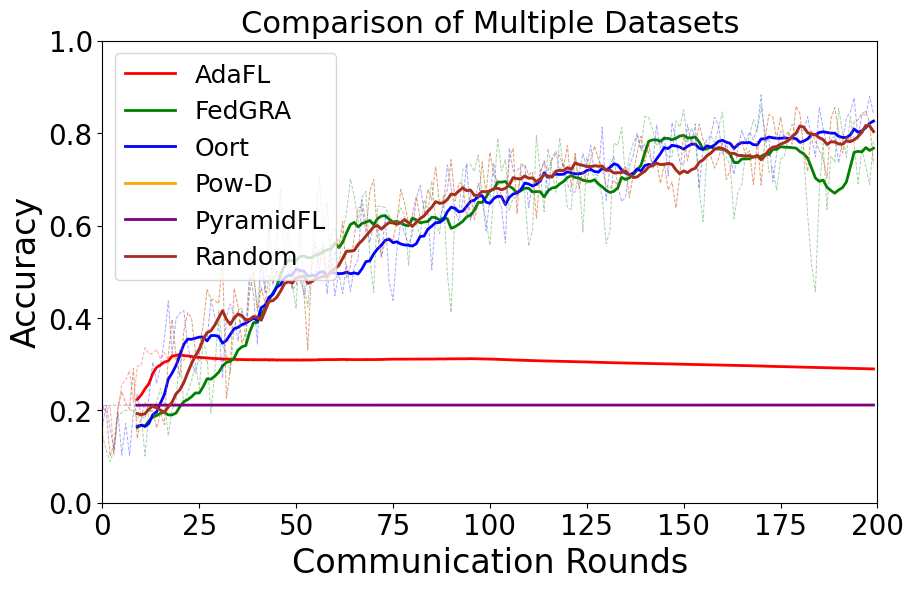

In [5]:
# Example 3: Compare multiple datasets
# Load additional files for comparison
files_compare = [
    "./mnist_series/train-20260210_020308-eb4fea9f.csv",
    "./mnist_series/train-20260210_020558-eb4fea9f.csv",
    "./mnist_series/train-20260210_021936-eb4fea9f.csv",
    "./mnist_series/train-20260210_022219-eb4fea9f.csv",
    "./mnist_series/train-20260210_022509-eb4fea9f.csv",
    "./mnist_series/train-20260210_022754-eb4fea9f.csv",
]

# Load all files more efficiently (use header=2 for these CSVs)
data_dict = {}
for i, file_path in enumerate(files_compare):
    df_temp = read_training_csv([file_path], columns=["accuracy"], header=1)
    data_dict[f"Dataset {i+1}"] = df_temp["accuracy"]

# Provide sufficient colors for all datasets
colors_list = ["red", "green", "blue", "orange", "purple", "brown"]

# legend_map must be a dict mapping the keys in data_dict to desired legend labels
legend_map = {
    "Dataset 1": "AdaFL",
    "Dataset 2": "FedGRA",
    "Dataset 3": "Oort",
    "Dataset 4": "Pow-D",
    "Dataset 5": "PyramidFL",
    "Dataset 6": "Random",
}

plot_learning_curves(
    data_dict,
    x_range=200,
    colors=colors_list,
    legend_map=legend_map,
    title="Comparison of Multiple Datasets",
    y_label="Accuracy",
    y_lim=[0, 1],
    figsize=(10, 6),
    window_size=10,
    is_legend=True
)


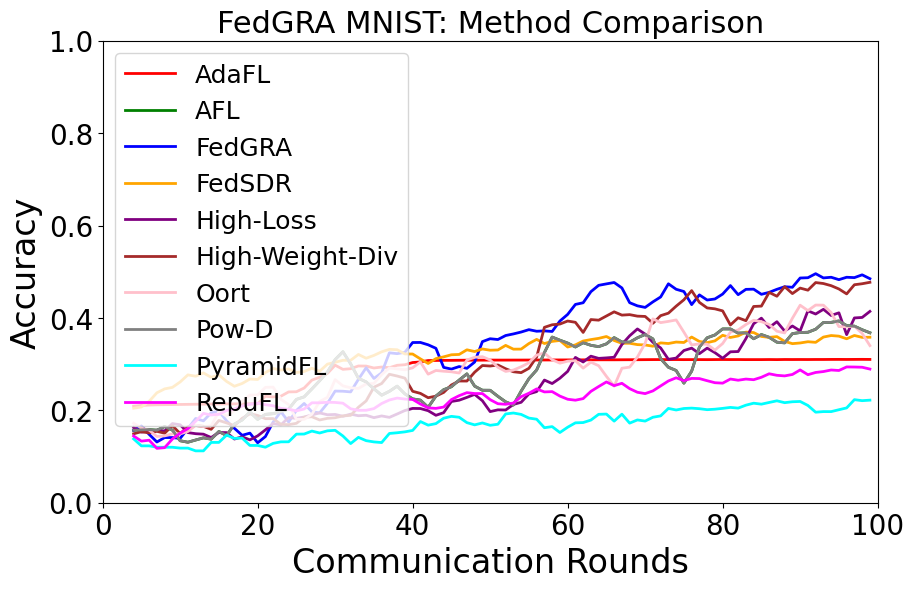

{'AdaFL': 0      0.2040
 1      0.2080
 2      0.2098
 3      0.2113
 4      0.2116
         ...  
 96     0.3097
 97     0.3104
 98     0.3107
 99     0.3097
 100    0.3102
 Name: accuracy, Length: 101, dtype: float64,
 'AFL': 0      0.2091
 1      0.1945
 2      0.1085
 3      0.1155
 4      0.1564
         ...  
 96     0.3527
 97     0.3470
 98     0.3620
 99     0.3636
 100    0.5132
 Name: accuracy, Length: 101, dtype: float64,
 'FedGRA': 0      0.1384
 1      0.1953
 2      0.1841
 3      0.1626
 4      0.1032
         ...  
 96     0.4940
 97     0.5003
 98     0.4941
 99     0.4423
 100    0.5289
 Name: accuracy, Length: 101, dtype: float64,
 'FedSDR': 0      0.2090
 1      0.1495
 2      0.1916
 3      0.2108
 4      0.2621
         ...  
 96     0.3387
 97     0.3827
 98     0.3655
 99     0.3631
 100    0.3406
 Name: accuracy, Length: 101, dtype: float64,
 'High-Loss': 0      0.1616
 1      0.1822
 2      0.1724
 3      0.1842
 4      0.1136
         ...  
 96     0.2855
 9

In [2]:

# Plot all methods under fedgra/mnist — one curve per method (auto-parsed from Config header)
legend_map = {
    "adafl":                   "AdaFL",
    "afl":                     "AFL",
    "fedgra":                  "FedGRA",
    "fedsdr":                  "FedSDR",
    "high_loss":               "High-Loss",
    "high_weight_divergence":  "High-Weight-Div",
    "oort":                    "Oort",
    "powd":                    "Pow-D",
    "pyramidfl":               "PyramidFL",
    "repufl":                  "RepuFL",
}

plot_fedgra_learning_curves(
    files="./mnist",
    metric="accuracy",
    auto_legend=True,
    legend_map=legend_map,
    x_range=100,
    title="FedGRA MNIST: Method Comparison",
    y_label="Accuracy",
    y_lim=(0, 1),
    figsize=(10, 6),
    window_size=5,
    is_legend=True,
    plot_raw=False,
    sort_files=True,
)
